In [1]:
# [Markdown]
# # 🛡️ Lab 03: Continuous Risk Officer & Kelly Sizing
# **Upgrades Applied:**
# 1. Continuous PnL Target (Replacing binary Win/Loss)
# 2. Dynamic Triple-Barrier (Expanding based on AI Volatility forecast)
# 3. CatBoost Regressor (For Kelly Criterion Position Sizing)

import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostRegressor, Pool
import matplotlib.pyplot as plt

# --- MUST EXACTLY MATCH NOTEBOOK 02 ---
class MultiTaskQuantformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.proj = nn.Linear(num_features, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*2, batch_first=True, dropout=0.2
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc_shared = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(0.2))
        self.head_dir = nn.Linear(32, 1) 
        self.head_mag = nn.Linear(32, 1) 
        self.head_vol = nn.Sequential(nn.Linear(32, 1), nn.Softplus()) 
        
    def forward(self, x):
        shared_features = self.fc_shared(self.transformer(self.proj(x))[:, -1, :])
        return self.head_dir(shared_features), self.head_mag(shared_features), self.head_vol(shared_features)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"⚡ Compute Device: {device}")

⚡ Compute Device: mps


In [2]:
# [Markdown]
# ### 1. Run Alpha Inference
# Feed the data through our new Multi-Task Engine to get Direction, Magnitude, and Volatility forecasts.

save_dir = '../data/processed/'
df = pd.read_parquet(os.path.join(save_dir, 'clean_tensor.parquet')).dropna()

# Load Artifacts
scaler = joblib.load(os.path.join(save_dir, 'core_scaler.pkl'))
pca = joblib.load(os.path.join(save_dir, 'core_pca.pkl'))
tech_features = joblib.load(os.path.join(save_dir, 'core_features.pkl'))
macro_cols = [c for c in df.columns if c.startswith('macro_emb_')]

# Reconstruct
macro_pca = pca.transform(df[macro_cols])
X_raw = np.hstack([df[tech_features].values, macro_pca])
X_scaled = scaler.transform(X_raw)

# Load Multi-Task Model
model = MultiTaskQuantformer(num_features=X_scaled.shape[1]).to(device)
model.load_state_dict(torch.load(os.path.join(save_dir, 'core_quantformer.pth'), map_location=device))
model.eval()

# Inference arrays
SEQ_LEN = 32
prob_dir, exp_mag, exp_vol = np.full(len(df), np.nan), np.full(len(df), np.nan), np.full(len(df), np.nan)

print(f"🧠 Running Multi-Task Inference on {len(df)} bars...")
with torch.no_grad():
    for i in range(SEQ_LEN, len(df)):
        x_seq = X_scaled[i - SEQ_LEN : i]
        tensor_input = torch.tensor(x_seq, dtype=torch.float32).unsqueeze(0).to(device)
        logit_d, pred_m, pred_v = model(tensor_input)
        
        prob_dir[i] = torch.sigmoid(logit_d).item()
        exp_mag[i] = pred_m.item()
        exp_vol[i] = pred_v.item()

df['alpha_prob'] = prob_dir
df['alpha_mag'] = exp_mag
df['alpha_vol'] = exp_vol

# Base Conviction (Only propose trades if magnitude > spread friction)
FRICTION = 0.00005
df['base_signal'] = np.select(
    [(df['alpha_prob'] > 0.60) & (df['alpha_mag'] > FRICTION), 
     (df['alpha_prob'] < 0.40) & (df['alpha_mag'] < -FRICTION)],
    [1, -1], default=0
)

active_setups = df[df['base_signal'] != 0].copy()
print(f"🎯 Quality Setups Proposed by Alpha Engine: {len(active_setups)}")

🧠 Running Multi-Task Inference on 99987 bars...
🎯 Quality Setups Proposed by Alpha Engine: 26540


In [5]:
# [Markdown]
# ### 2. Dynamic Triple-Barrier Labeling
# Instead of fixed ATR, barriers expand based on the Transformer's `alpha_vol`.
# Instead of 1 or 0, the target is the actual Continuous Log Return (PnL) of the outcome.

def apply_dynamic_barrier(full_df, setups_df, horizon=32):
    print("🚧 Applying Volatility-Adjusted Triple-Barrier...")
    actual_pnls = []
    
    close_arr = full_df['close'].values
    high_arr = full_df['high'].values
    low_arr = full_df['low'].values
    
    full_df['idx'] = np.arange(len(full_df))
    setup_indices = full_df.loc[setups_df.index, 'idx'].values
    
    for loc in setup_indices:
        if loc + 1 >= len(full_df): 
            actual_pnls.append(np.nan)
            continue
            
        direction = full_df.iloc[loc]['base_signal']
        entry_price = close_arr[loc]
        
        # 🛡️ FIX 1: Prevent Division by Zero (Skip bad data rows)
        if entry_price <= 0:
            actual_pnls.append(np.nan)
            continue
        
        # 🛡️ DYNAMIC BARRIERS: Driven by AI Volatility Forecast
        expected_vol = full_df.iloc[loc]['alpha_vol']
        if pd.isna(expected_vol) or expected_vol <= 0: expected_vol = 0.0010
            
        stop_dist = expected_vol * 1.5 
        take_dist = expected_vol * 3.0
        
        stop_price = entry_price - (direction * stop_dist)
        take_price = entry_price + (direction * take_dist)
        
        end_loc = min(loc + horizon + 1, len(full_df))
        future_highs = high_arr[loc+1 : end_loc]
        future_lows = low_arr[loc+1 : end_loc]
        future_closes = close_arr[loc+1 : end_loc]
        
        if direction == 1:
            stops = np.where(future_lows <= stop_price)[0]
            takes = np.where(future_highs >= take_price)[0]
        else:
            stops = np.where(future_highs >= stop_price)[0]
            takes = np.where(future_lows <= take_price)[0]
            
        stop_idx = stops[0] if len(stops) > 0 else 9999
        take_idx = takes[0] if len(takes) > 0 else 9999
        
        first_event = min(take_idx, stop_idx)
        
        # CALCULATE CONTINUOUS PnL
        if first_event == 9999:
            # Time exit: Return achieved at the end of the horizon
            exit_price = future_closes[-1]
        elif first_event == take_idx:
            # Hit Take Profit
            exit_price = take_price
        else:
            # Hit Stop Loss
            exit_price = stop_price
            
        # 🛡️ FIX 2: Prevent log(0) if exit price is corrupted
        if exit_price <= 0:
            actual_pnls.append(np.nan)
            continue
            
        trade_return = np.log(exit_price / entry_price) * direction
        actual_pnls.append(trade_return - FRICTION) # Apply transaction cost
            
    setups_df['target_pnl'] = actual_pnls
    return setups_df.dropna(subset=['target_pnl'])

labeled_setups = apply_dynamic_barrier(df, active_setups)
print(f"📊 Average Base PnL per Trade: {labeled_setups['target_pnl'].mean() * 10000:.2f} bps")

🚧 Applying Volatility-Adjusted Triple-Barrier...
📊 Average Base PnL per Trade: 0.25 bps


In [6]:
# [Markdown]
# ### 3. Train the Continuous Risk Regressor (CatBoost)
# We feed the Alpha Agent's "thoughts" (`alpha_vol`, `alpha_mag`) into the Risk Officer so it can learn when the Transformer is being overconfident.

# Notice we include the Alpha outputs as features!
meta_features = tech_features + ['active_session_name', 'alpha_prob', 'alpha_mag', 'alpha_vol']
cat_features = ['active_session_name']

X_meta = labeled_setups[meta_features].copy()
y_meta = labeled_setups['target_pnl'] # Continuous Target

X_meta['active_session_name'] = X_meta['active_session_name'].astype(str)

split_idx = int(len(X_meta) * 0.8)
X_train, X_val = X_meta.iloc[:split_idx], X_meta.iloc[split_idx:]
y_train, y_val = y_meta.iloc[:split_idx], y_meta.iloc[split_idx:]

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

# Changed to Regressor
meta_model = CatBoostRegressor(
    iterations=800, 
    learning_rate=0.03, 
    depth=6, 
    eval_metric='RMSE', # Optimizing for Profit accuracy
    random_seed=42, 
    early_stopping_rounds=50, 
    verbose=100
)

print("🚀 Training Continuous Risk Regressor...")
meta_model.fit(train_pool, eval_set=val_pool)

🚀 Training Continuous Risk Regressor...
0:	learn: 0.0002152	test: 0.0001971	best: 0.0001971 (0)	total: 63.8ms	remaining: 51s
100:	learn: 0.0001108	test: 0.0001763	best: 0.0001761 (84)	total: 411ms	remaining: 2.84s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.0001754737652
bestIteration = 121

Shrink model to first 122 iterations.


CatBoostRegressor(depth=6, early_stopping_rounds=50, eval_metric='RMSE', iterations=800, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

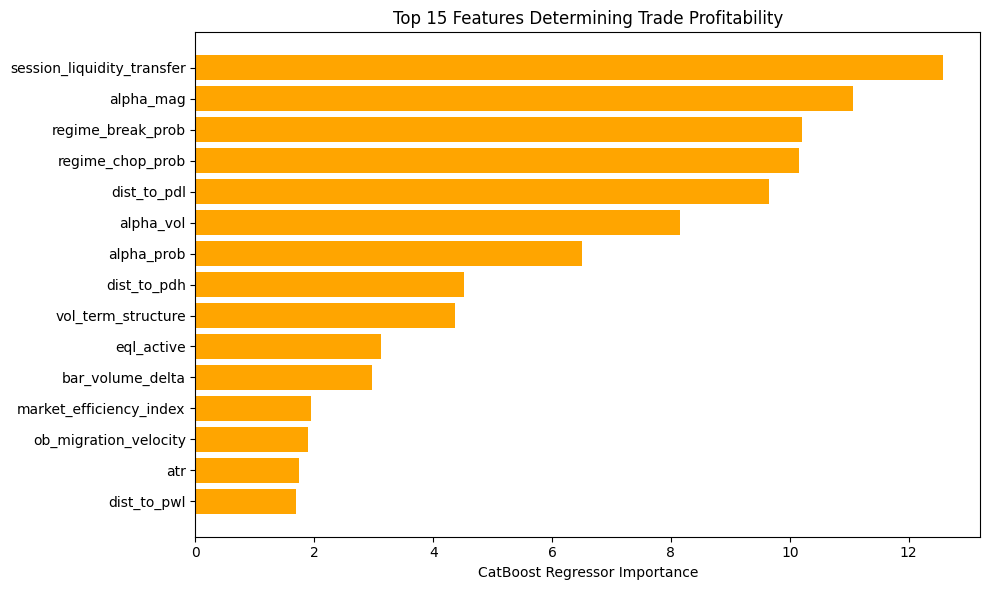

✅ Continuous Risk Model exported to: ../models/meta_model.cbm

🔮 Live Sizing Simulation (First 5 Val Setups):
Setup 1: Expected PnL +0.7 bps -> ✅ EXECUTE (Size: 0.07x)
Setup 2: Expected PnL +0.7 bps -> ✅ EXECUTE (Size: 0.07x)
Setup 3: Expected PnL +0.7 bps -> ✅ EXECUTE (Size: 0.07x)
Setup 4: Expected PnL +0.7 bps -> ✅ EXECUTE (Size: 0.07x)
Setup 5: Expected PnL +0.7 bps -> ✅ EXECUTE (Size: 0.07x)


In [7]:
# [Markdown]
# ### 4. Feature Importance & Kelly Export
# In live trading, if `predicted_pnl` is negative, we Veto. If it's positive, we scale our lot size linearly with the expected profit.

importance = meta_model.get_feature_importance()
imp_df = pd.DataFrame({'Feature': meta_features, 'Importance': importance}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(imp_df['Feature'].head(15)[::-1], imp_df['Importance'].head(15)[::-1], color='orange')
plt.title("Top 15 Features Determining Trade Profitability")
plt.xlabel("CatBoost Regressor Importance")
plt.tight_layout()
plt.show()

# Export Model
model_path = '../models/meta_model.cbm'
os.makedirs('../models', exist_ok=True)
meta_model.save_model(model_path)
print(f"✅ Continuous Risk Model exported to: {model_path}")

# Simulated Kelly Output
sample_prediction = meta_model.predict(X_val.iloc[0:5])
print("\n🔮 Live Sizing Simulation (First 5 Val Setups):")
for i, pred_pnl in enumerate(sample_prediction):
    if pred_pnl <= 0:
        print(f"Setup {i+1}: Expected PnL {pred_pnl*10000:.1f} bps -> 🛑 VETO TRADE")
    else:
        # Half-Kelly Approximation: Scale size by expected return
        sizing_multiplier = min(pred_pnl * 1000, 3.0) # Max 3x leverage
        print(f"Setup {i+1}: Expected PnL +{pred_pnl*10000:.1f} bps -> ✅ EXECUTE (Size: {sizing_multiplier:.2f}x)")